In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [3]:
df = pd.read_csv('traffic.csv')

In [4]:
df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [5]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140082 entries, 0 to 140081
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    140082 non-null  object
 1   date     140082 non-null  object
 2   country  140075 non-null  object
 3   city     140075 non-null  object
 4   artist   140059 non-null  object
 5   album    140078 non-null  object
 6   track    140078 non-null  object
 7   isrc     135959 non-null  object
 8   linkid   140081 non-null  object
dtypes: object(9)
memory usage: 9.6+ MB


In [6]:
df.isnull().sum()

,0
event,0
date,0
country,7
city,7
artist,23
album,4
track,4
isrc,4123
linkid,1


In [7]:
for col in df.columns:
      df[col].fillna('Unknown', inplace=True)

/tmp/ipykernel_806/928346619.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('Unknown', inplace=True)


In [8]:
df.isnull().sum()

,0
event,0
date,0
country,0
city,0
artist,0
album,0
track,0
isrc,0
linkid,0


In [9]:
df.duplicated().sum()

np.int64(55892)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.shape

(84190, 9)

In [12]:
df['date'] = pd.to_datetime(df['date'])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84190 entries, 0 to 140081
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   event    84190 non-null  object        
 1   date     84190 non-null  datetime64[ns]
 2   country  84190 non-null  object        
 3   city     84190 non-null  object        
 4   artist   84190 non-null  object        
 5   album    84190 non-null  object        
 6   track    84190 non-null  object        
 7   isrc     84190 non-null  object        
 8   linkid   84190 non-null  object        
dtypes: datetime64[ns](1), object(8)
memory usage: 6.4+ MB


In [14]:
df['Year'] = df['date'].dt.year
df['Month'] = df['date'].dt.month
df['Day'] = df['date'].dt.day_name()
df['Hour'] = df['date'].dt.hour

In [15]:
df.head()

,event,date,country,city,artist,album,track,isrc,linkid,Year,Month,Day,Hour
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8,2021,8,Saturday,0
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2,2021,8,Saturday,0
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd,2021,8,Saturday,0
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8,2021,8,Saturday,0
5,click,2021-08-21,United States,Los Angeles,KenTheMan,I'm Perfect,I'm Perfect,US39N2102090,190c7170-4044-4c97-9709-926917155b02,2021,8,Saturday,0


In [16]:
total_sessions = df['linkid'].nunique()

print("Total Sessions:", total_sessions)

Total Sessions: 2971


In [17]:
df['user'] = df['city'] + '_' + df['country']

total_users = df['user'].nunique()

print("Estimated Users:", total_users)

Estimated Users: 10260


In [18]:
events_per_session = df.groupby('linkid').size()

bounce_sessions = (events_per_session == 1).sum()

bounce_rate = (bounce_sessions / total_sessions) * 100

print("Bounce Rate:", round(bounce_rate, 2), "%")

Bounce Rate: 49.14 %


In [19]:
top_artists = df['artist'].value_counts().head(10)

print(top_artists)

artist
Tesher                                                          6241
Anne-Marie                                                      2960
Tundra Beats                                                    2940
Surf Mesa, Emilee                                               2170
Roddy Ricch                                                     2163
DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna    2039
Olivia Rodrigo                                                  1982
Reyanna Maria                                                   1945
50 Cent, Olivia                                                 1678
PinkPantheress                                                  1574
Name: count, dtype: int64


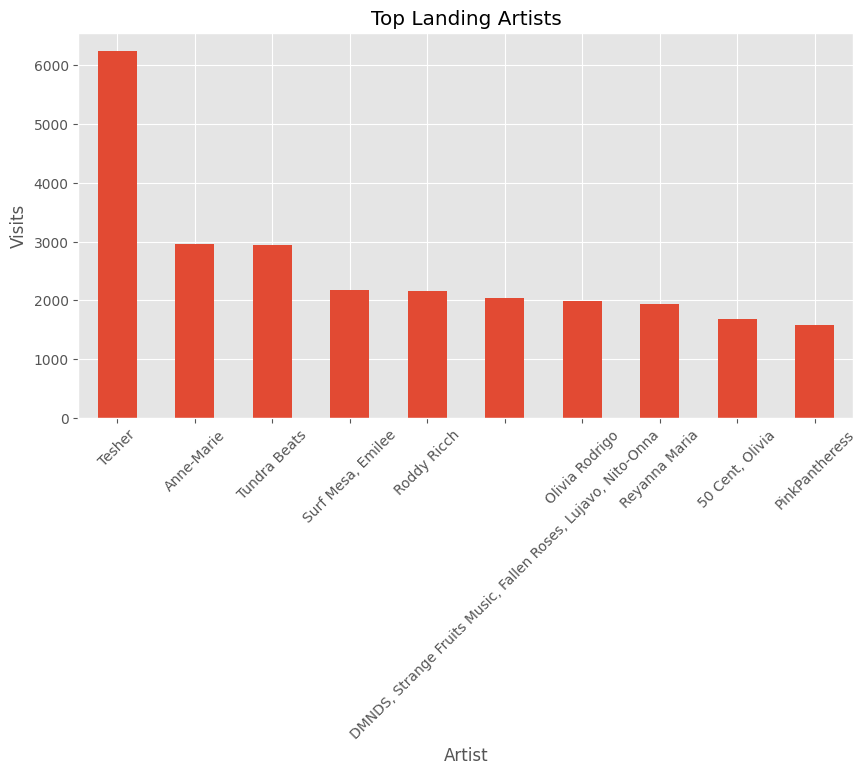

In [20]:
top_artists.plot(kind='bar', figsize=(10,5))

plt.title('Top Landing Artists')
plt.xlabel('Artist')
plt.ylabel('Visits')
plt.xticks(rotation=45)

plt.show()

In [21]:
top_countries = df['country'].value_counts().head(10)

print(top_countries)

country
United States     18139
India             14001
France             7239
Saudi Arabia       6388
United Kingdom     3238
Germany            2550
Pakistan           1987
Iraq               1907
Canada             1805
Turkey             1577
Name: count, dtype: int64


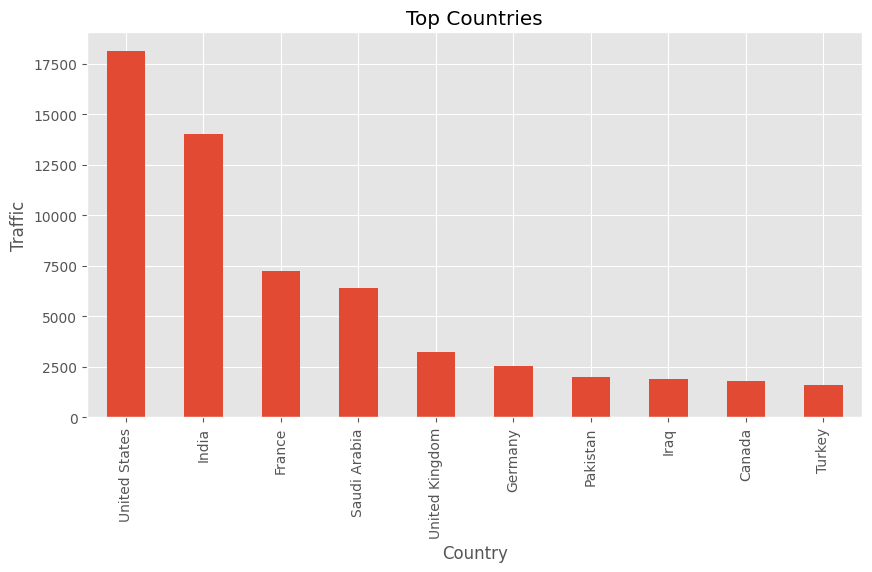

In [22]:
top_countries.plot(kind='bar', figsize=(10,5))

plt.title('Top Countries')
plt.xlabel('Country')
plt.ylabel('Traffic')

plt.show()

In [23]:
df['event'].value_counts()

,count
event,
pageview,34983
click,32499
preview,16708


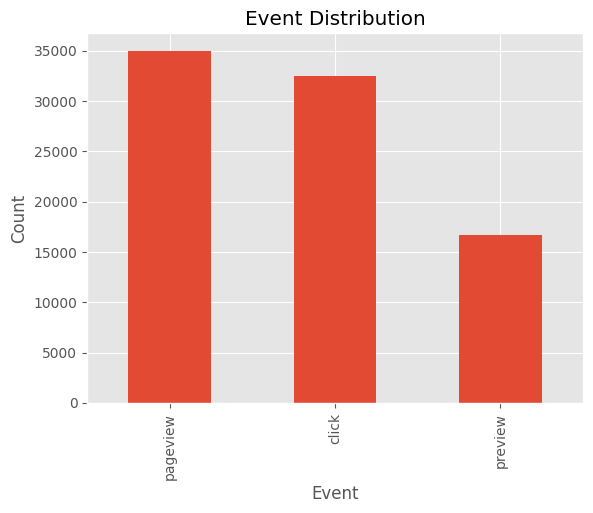

In [24]:
df['event'].value_counts().plot(kind='bar')

plt.title('Event Distribution')
plt.xlabel('Event')
plt.ylabel('Count')

plt.show()

In [27]:
top_countries = df['country'].value_counts().head(10)
print(top_countries)

country
United States     18139
India             14001
France             7239
Saudi Arabia       6388
United Kingdom     3238
Germany            2550
Pakistan           1987
Iraq               1907
Canada             1805
Turkey             1577
Name: count, dtype: int64


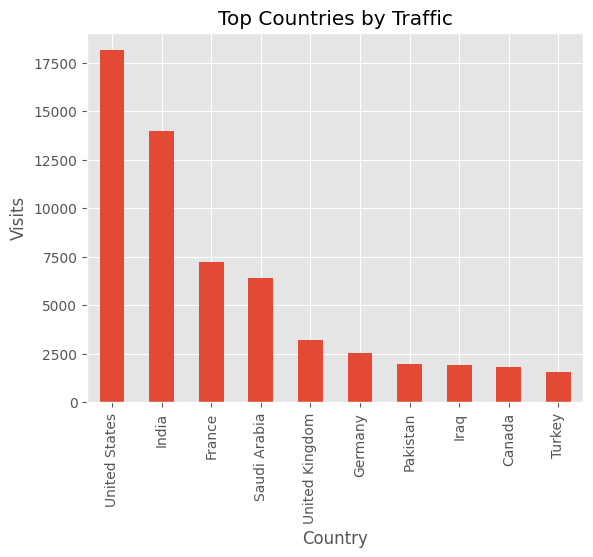

In [28]:
top_countries.plot(kind='bar')

plt.title("Top Countries by Traffic")
plt.xlabel("Country")
plt.ylabel("Visits")

plt.show()

In [29]:
top_cities = df['city'].value_counts().head(10)
print(top_cities)

city
Unknown        6320
Jeddah         2166
Riyadh         1943
Hyderabad       866
Dammam          815
Jaipur          708
Delhi           701
Lucknow         696
Kuwait City     670
Ahmedabad       647
Name: count, dtype: int64


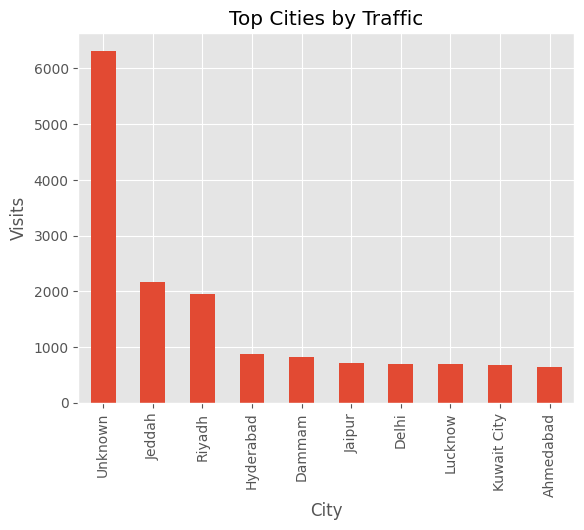

In [30]:
top_cities.plot(kind='bar')

plt.title("Top Cities by Traffic")
plt.xlabel("City")
plt.ylabel("Visits")

plt.show()

In [31]:
top_tracks = df['track'].value_counts().head(10)
print(top_tracks)

track
Jalebi Baby                              6241
Beautiful                                2965
Beautiful Day                            2940
ily (i love you baby) (feat. Emilee)     2170
Late At Night                            2128
So Pretty                                2061
Calabria (feat. Lujavo & Nito-Onna)      2039
Candy Shop                               1681
Summer of Love (Shawn Mendes & Tainy)    1554
Build a Bitch                            1487
Name: count, dtype: int64


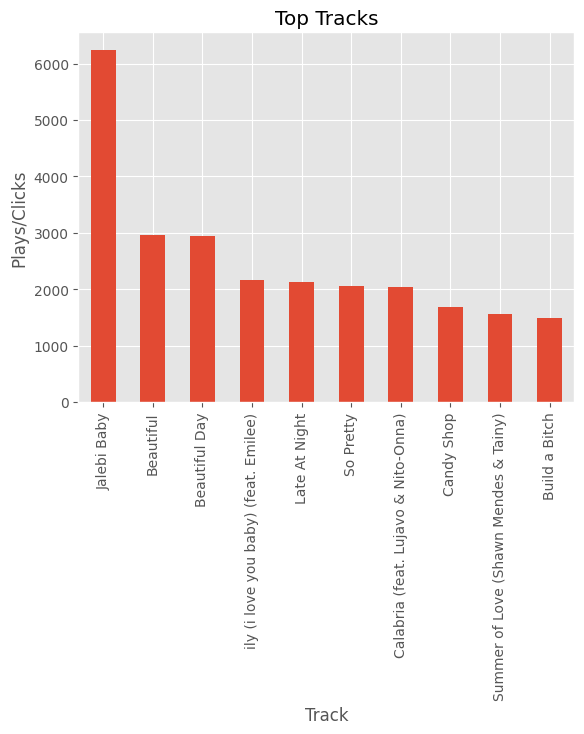

In [32]:
top_tracks.plot(kind='bar')

plt.title("Top Tracks")
plt.xlabel("Track")
plt.ylabel("Plays/Clicks")

plt.show()

In [34]:
top_users = df['user'].value_counts().head(10)
print(top_users)

user
Jeddah_Saudi Arabia      2166
Riyadh_Saudi Arabia      1943
Unknown_France           1101
Unknown_United States     925
Hyderabad_India           820
Dammam_Saudi Arabia       815
Jaipur_India              708
Delhi_India               699
Lucknow_India             696
Kuwait City_Kuwait        670
Name: count, dtype: int64


In [35]:
df['artist'].value_counts().head(10)

,count
artist,
Tesher,6241
Anne-Marie,2960
Tundra Beats,2940
"Surf Mesa, Emilee",2170
Roddy Ricch,2163
"DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna",2039
Olivia Rodrigo,1982
Reyanna Maria,1945
"50 Cent, Olivia",1678


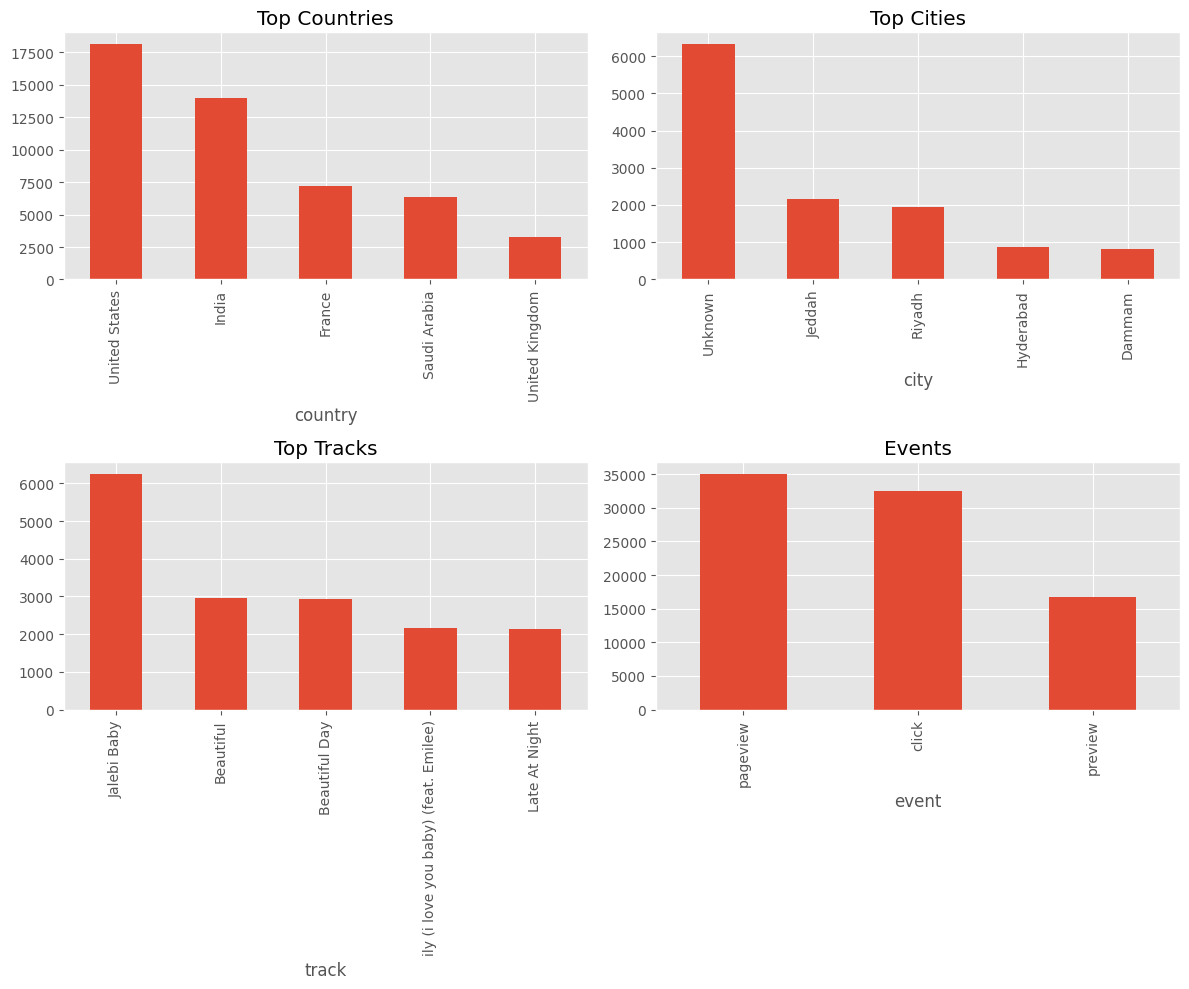

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

df['country'].value_counts().head(5).plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title("Top Countries")

df['city'].value_counts().head(5).plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title("Top Cities")

df['track'].value_counts().head(5).plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title("Top Tracks")

df['event'].value_counts().head(5).plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title("Events")

plt.tight_layout()
plt.show()

**📊 Website Traffic Analysis Report**

🔹 Overview

This analysis was performed on website streaming traffic data to understand user behavior, content engagement, and geographic distribution.

**🔹 Key Metrics**

Total Users: (from df['user'].nunique())

Total Events: (len(df))

Bounce Rate: 49.14%

Peak Activity Hours identified from analysis

**🔹 Key Insights**

Certain countries dominate traffic distribution

A few cities generate majority of engagement

Specific tracks and artists are highly popular

User activity peaks during specific hours of the day

Engagement is concentrated among active users

**🔹 Recommendations**

Focus marketing on top-performing regions

Improve engagement in low-traffic countries

Promote top tracks and artists

Schedule content releases during peak hours

Personalize user experience using behavior data